# Data Understanding
# CRISP-DM – Fase 2

<hr>

In [1]:
# Importação das libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from scipy.stats import f_oneway


# Paths do projeto

BASE_DIR = Path().resolve()

DATA_DIR = BASE_DIR / "data"
DATA_PREPARED_DIR = DATA_DIR / "prepared"

OUTPUTS_DIR = BASE_DIR / "outputs"
FIGURES_BASE_DIR = OUTPUTS_DIR / "figures"

FIGURES_UNDERSTANDING_DIR = FIGURES_BASE_DIR / "understanding"
FIGURES_PREPARATION_DIR = FIGURES_BASE_DIR / "preparation"
FIGURES_MODELING_DIR = FIGURES_BASE_DIR / "modeling"

# Criar pastas automaticamente
DATA_PREPARED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_UNDERSTANDING_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_PREPARATION_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_MODELING_DIR.mkdir(parents=True, exist_ok=True)

# Carregar o dataset
DATASET_PATH = BASE_DIR / "HR-Intern-Retention_Dataset.csv"

df_raw = pd.read_csv(DATASET_PATH)

# Exibir as primeiras linhas do dataset
df_raw.head()

,Intern_ID,Age,Major,Internship_Duration_Months,Department,Supervisor_Evaluation,Salary,Attendance_%,Retained
0,1,24,IT,20,Legal,1.8,1956,71.9,1
1,2,21,Law,15,HR,1.2,1687,82.7,0
2,3,28,Engineering,3,HR,1.7,926,79.0,0
3,4,25,IT,23,Marketing,2.1,1929,86.5,1
4,5,22,Engineering,8,Legal,1.7,1808,97.5,1


<hr>

## 1. **Análise univariada**
<hr>

## Variável Target `Salary`

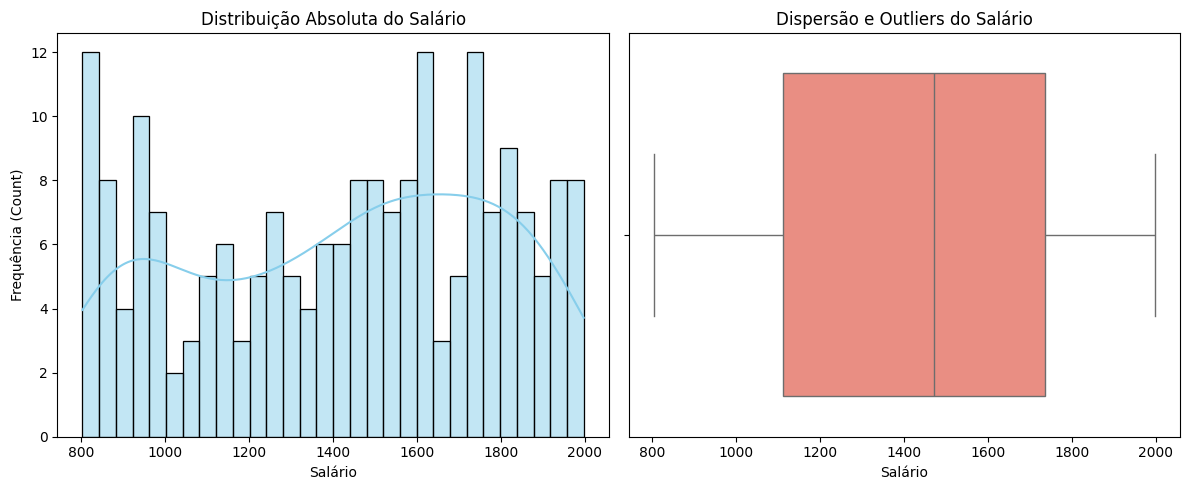

In [2]:
plt.figure(figsize=(12, 5))

# 1. Histograma: Frequência Absoluta
plt.subplot(1, 2, 1)
sns.histplot(df_raw['Salary'], bins=30, kde=True, color='skyblue')
plt.title('Distribuição Absoluta do Salário')
plt.xlabel('Salário')
plt.ylabel('Frequência (Count)')

# 2. Boxplot: Para análise de Outliers e Quartis
# (Muitas vezes mais útil que a frequência relativa isolada para variáveis contínuas)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_raw['Salary'], color='salmon')
plt.title('Dispersão e Outliers do Salário')
plt.xlabel('Salário')

plt.tight_layout()
plt.savefig(FIGURES_UNDERSTANDING_DIR / "analise_univariada_distribuicao_salario_hist_boxplot.png", bbox_inches="tight")
plt.show()

#### **Interpretação:**

- **Amplitude e Outliers:** Os salários variam entre 800 e 2000. O Boxplot confirma a ausência de outliers, indicando que não existem valores extremos que precisem de tratamento especial ou eliminação.

- **Forma da Distribuição:** O Histograma revela uma distribuição multimodal (vários picos). Isto sugere a existência de diferentes grupos salariais dentro da amostra, em vez de uma concentração única em torno de uma média.

- **Tendência Central:** A mediana situa-se próxima dos 1450. A dispersão é relativamente uniforme ao longo de todo o intervalo, sem uma inclinação (skewness) acentuada para os extremos.

## Variáveis numéricas

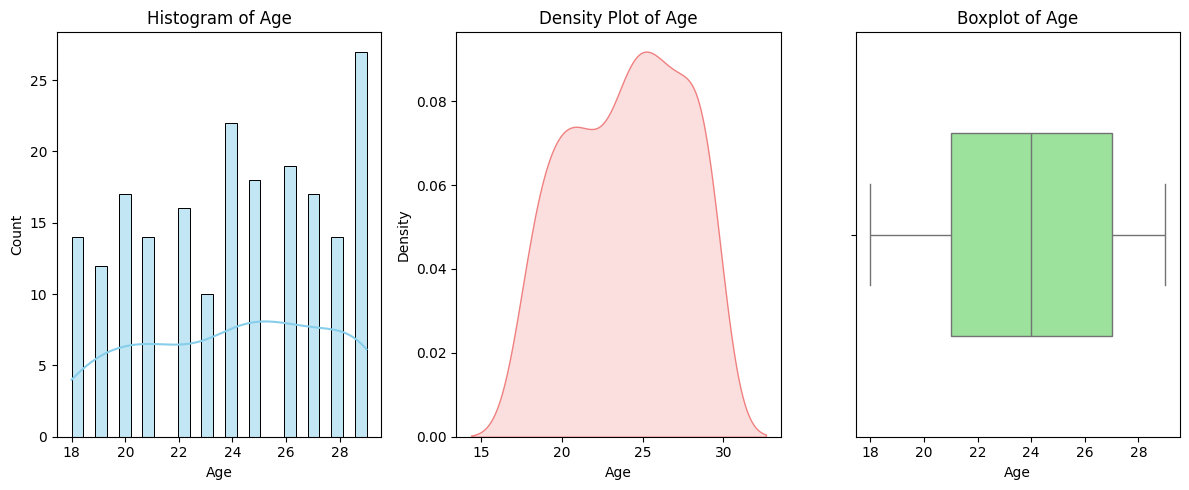

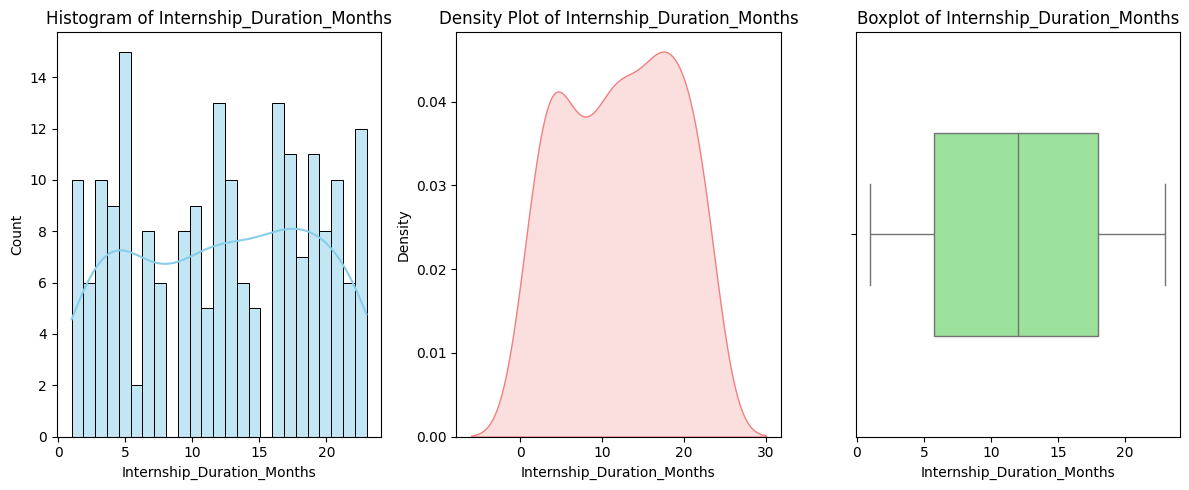

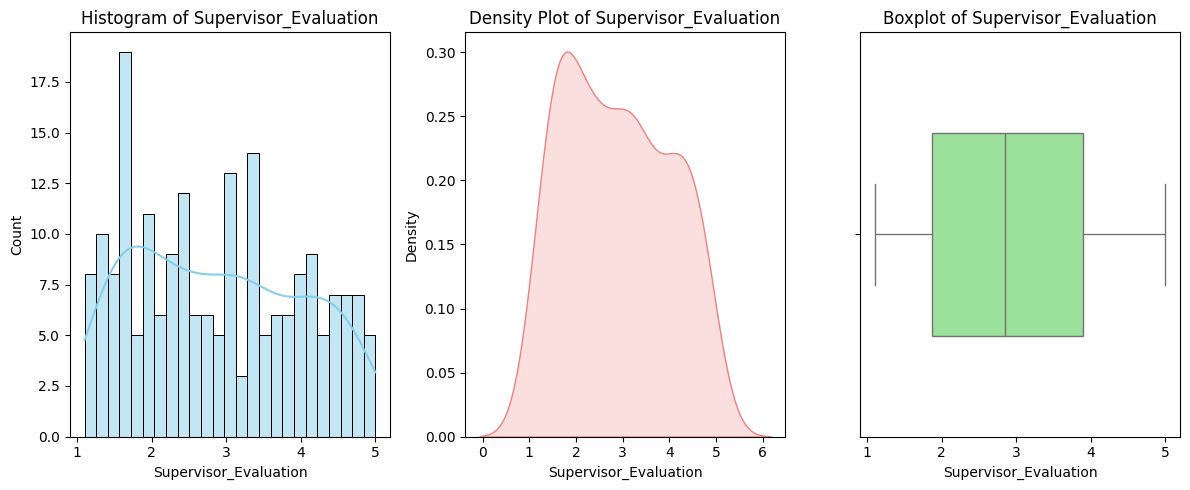

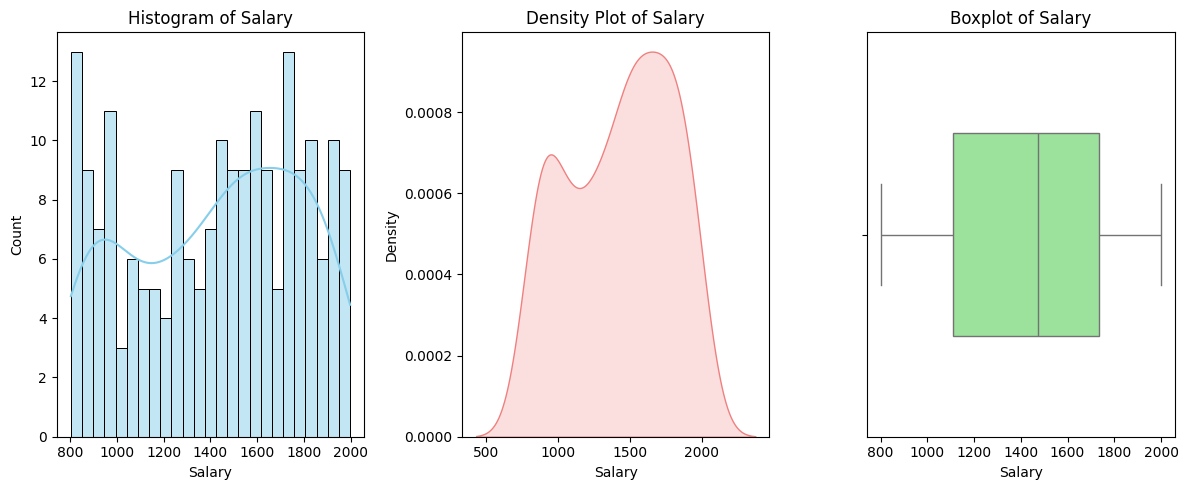

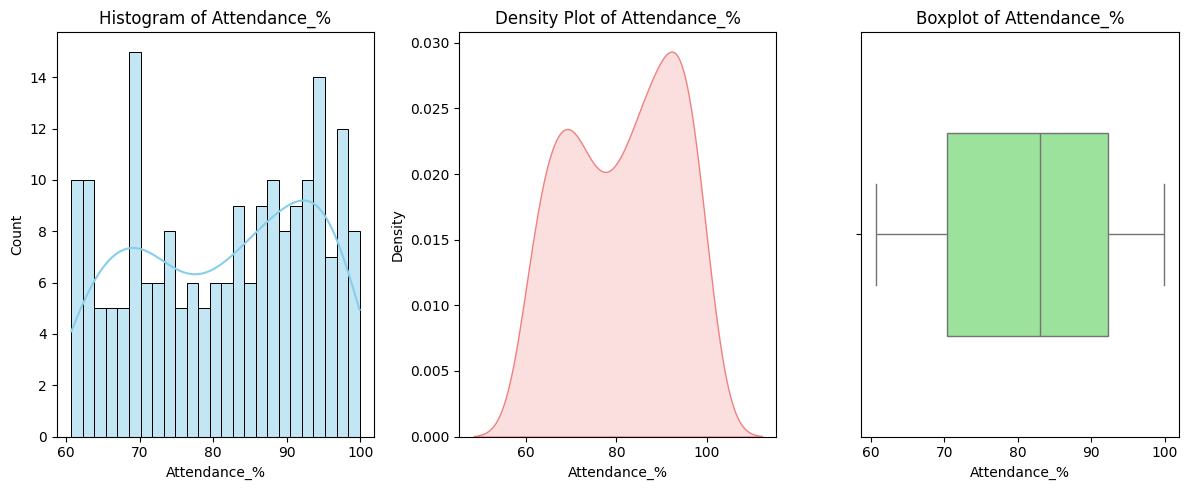

In [3]:
# Colunas numéricas
colunas_numericas = df_raw.select_dtypes(include=['int64', 'float64']).drop(["Intern_ID", "Retained"], axis=1).columns

# Análise univariada para colunas numéricas
for coluna in colunas_numericas:
    plt.figure(figsize=(12, 5))
    
    # Histograma
    plt.subplot(1, 3, 1)
    sns.histplot(data=df_raw, x=coluna, bins=25, kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {coluna}')
    
    # Distribuição de densidade
    plt.subplot(1, 3, 2)
    sns.kdeplot(df_raw[coluna], color='lightcoral', fill=True)
    plt.title(f'Density Plot of {coluna}')
    
    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(x=df_raw[coluna], color='lightgreen', showfliers=True, width=0.5)
    plt.title(f'Boxplot of {coluna}')
    
    plt.tight_layout()
    plt.savefig(FIGURES_UNDERSTANDING_DIR / f"analise_univariada_features_numericas_grafico_{coluna}.png", bbox_inches="tight")
    plt.show()

#### **Interpretação:**

- `Age`: Distribuição com ligeiro enviesamento à esquerda (concentração em idades mais avançadas no intervalo); o pico de frequência ocorre aos 29 anos, com mediana próxima dos 24.

- `Internship_Duration_Months`: Distribuição bimodal com picos nos 5 e 18 meses; a dispersão é ampla (1 a 23 meses), com uma mediana centralizada em torno dos 12 meses.

- `Supervisor_Evaluation`: Distribuição multimodal com maior concentração no limite inferior (aprox. 1.5 a 2.0); a mediana situa-se em torno de 2.9, indicando avaliações predominantemente moderadas a baixas.

- `Attendance_%`: Apresenta uma tendência bimodal, com picos de frequência em cerca de 70% e 95%; a maioria dos dados concentra-se acima dos 80%, sugerindo boa assiduidade geral.

## Variáveis categóricas

> Nota: Exploração realizada no Problema Analítico anterior de **Classificação**

C:\Users\Pedro\AppData\Local\Temp\ipykernel_20976\652667486.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x=coluna, order=df_raw[coluna].value_counts().index, palette='pastel')


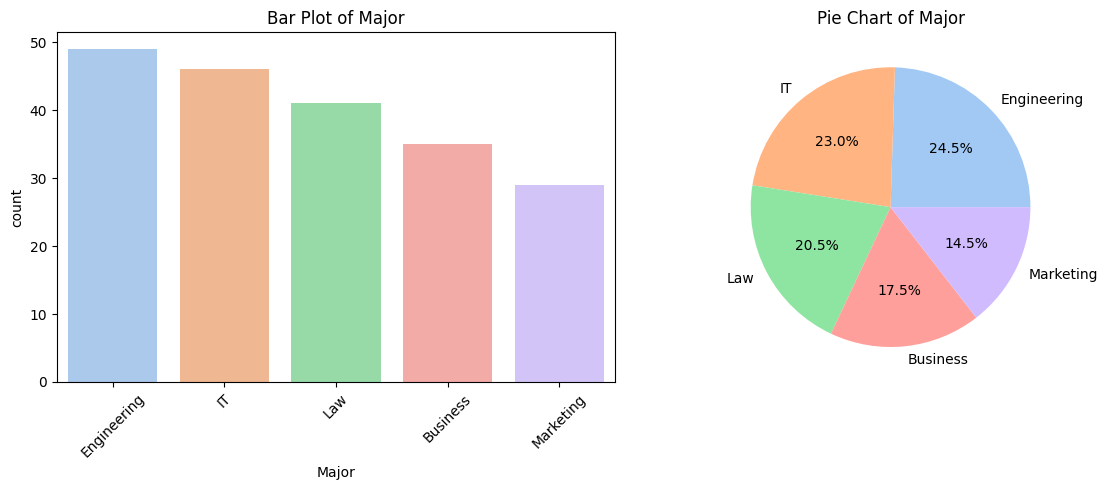

C:\Users\Pedro\AppData\Local\Temp\ipykernel_20976\652667486.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x=coluna, order=df_raw[coluna].value_counts().index, palette='pastel')


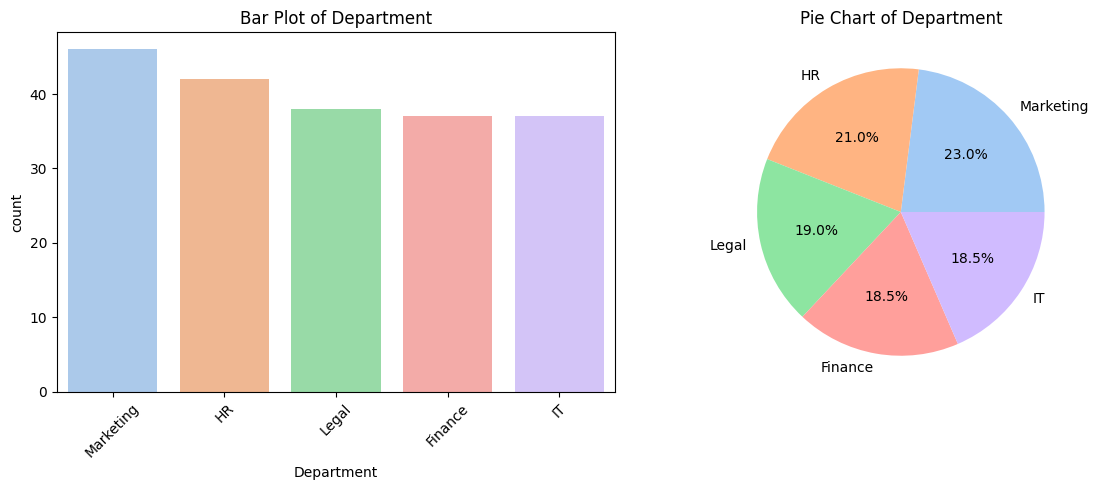

In [4]:
# Colunas categóricas
colunas_categoricas = df_raw.select_dtypes(include=['object']).columns

for coluna in colunas_categoricas:
    plt.figure(figsize=(12, 5))
    
    # Gráfico de barras (Seaborn)
    plt.subplot(1, 2, 1)
    sns.countplot(data=df_raw, x=coluna, order=df_raw[coluna].value_counts().index, palette='pastel')
    plt.title(f'Bar Plot of {coluna}')
    plt.xticks(rotation=45)
    
    # Gráfico de pie (Matplotlib)
    plt.subplot(1, 2, 2)
    df_raw[coluna].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel')
    )
    plt.title(f'Pie Chart of {coluna}')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.savefig(FIGURES_UNDERSTANDING_DIR / f"analise_univariada_features_categoricas_grafico_{coluna}.png", bbox_inches="tight")
    plt.show()

#### **Interpretação:**

- `Major`: Variável categórica que identifica a área académica, sendo Engineering a classe dominante (24,5%).

- `Department`: Variável categórica que define a alocação funcional, liderada pelo departamento de Marketing (23%).

- Ambas apresentam categorias equilibradas, sem dominância extrema. (Esta característica facilita o One-Hot encoding, uma vez que cada coluna dummy gerada terá variância suficiente (nem sempre 0 nem sempre 1), contribuindo de forma útil e informativa para o modelo, evitando a criação de variáveis quase constantes ou redundantes.)

<hr>

## 2. **Análise bivarida**
<hr>

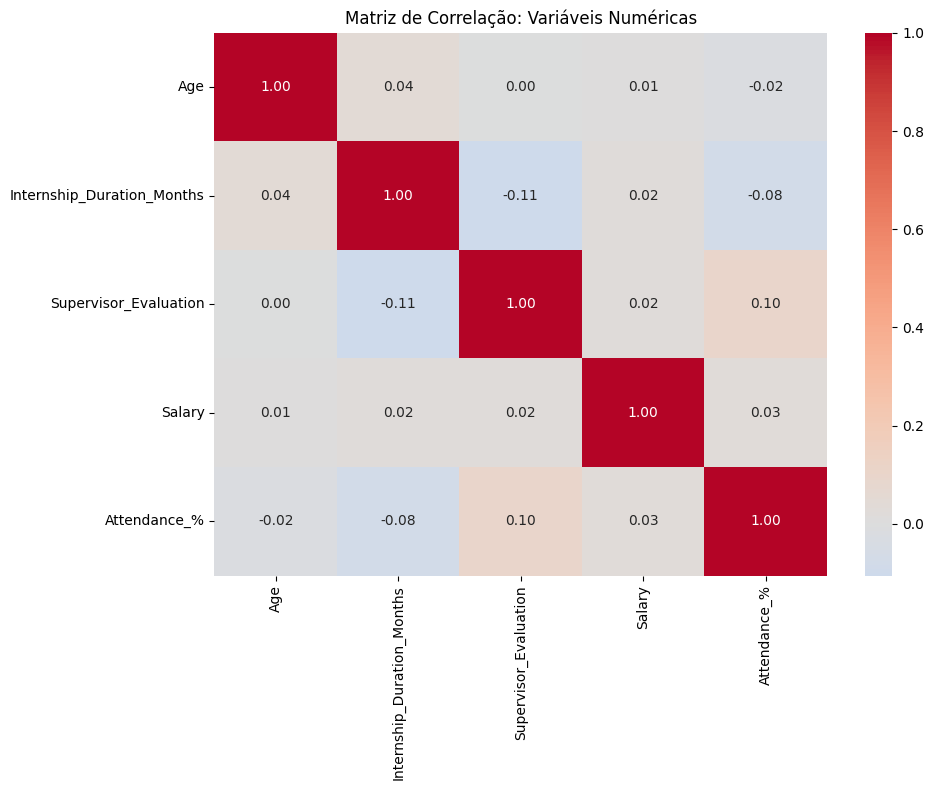

In [5]:
# Calcular correlação de todas as numéricas
corr = df_raw[colunas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Matriz de Correlação: Variáveis Numéricas')

plt.tight_layout()
plt.savefig(FIGURES_UNDERSTANDING_DIR / "analise_bivariada_matriz_correlacao.png", bbox_inches="tight")
plt.show()

#### **Interpretação:**

- **Salário Isolado:** O Salary tem correlação nula com todas as variáveis (máximo 0.03). Não é possível prever o salário linearmente com estes dados.

- **mpacto da Meritocracia Nulo:** A correlação entre Salary e Supervisor_Evaluation é praticamente inexistente ($r = 0.02$). Isto responde diretamente à pergunta de negócio: não, a avaliação do supervisor não tem qualquer peso linear estatisticamente relevante na variação do salário. O mérito, pelo menos de forma isolada e linear, não é recompensado financeiramente.

- **Senioridade e Assiduidade Ignoradas:** Variáveis como Age ($r = 0.01$), Internship_Duration_Months ($r = 0.02$) e Attendance_% ($r = 0.03$) apresentam valores tão próximos de zero que representam ruído estatístico. A empresa não paga mais a quem é mais velho, a quem está lá há mais tempo, ou a quem falta menos.

- **Independência das Features:** O único ponto "positivo" é a ausência de multicolinearidade. As variáveis preditoras não estão correlacionadas entre si (ex: Age e Supervisor_Evaluation têm $0.00$), o que significa que cada variável traz informação única. Sendo que essa informação não serve para explicar a variável alvo.

## Categóricas vs Target + Teste de Inferência Estatística (ANOVA)


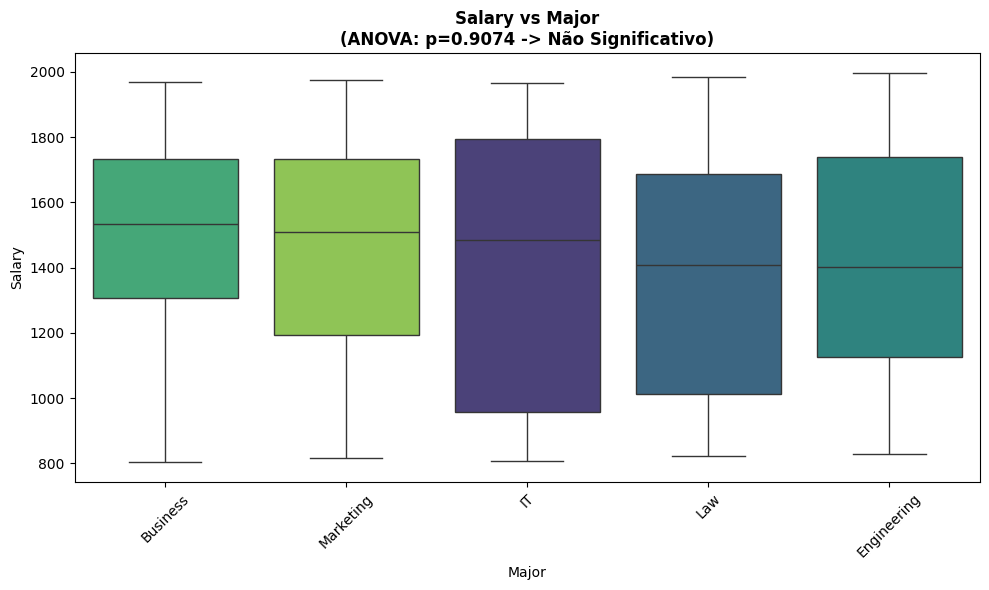

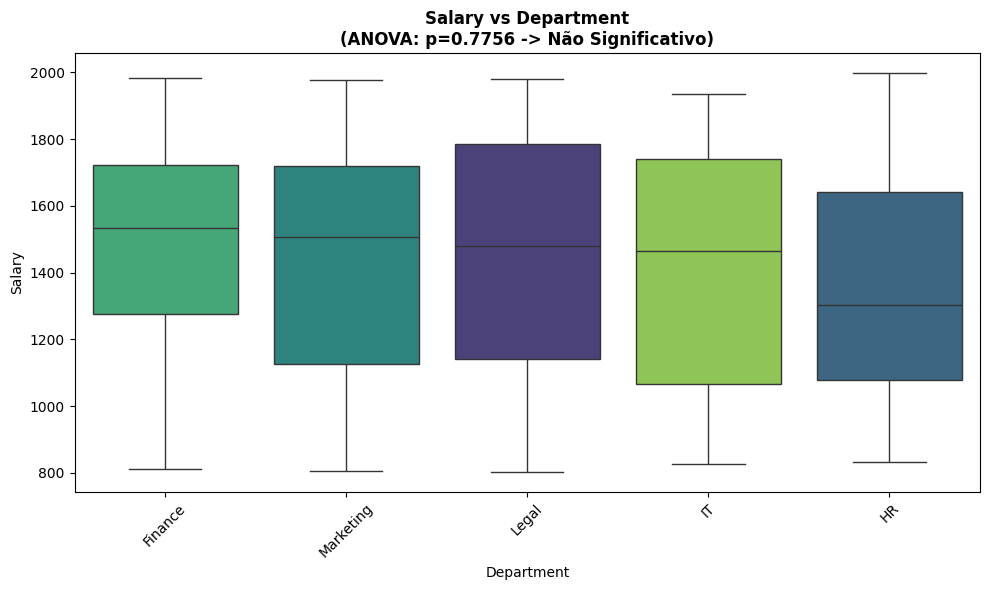

In [6]:
categoricas = ['Major', 'Department']

for var in categoricas:
    # 1. Preparar os grupos para a ANOVA
    grupos = [grupo['Salary'].values for name, grupo in df_raw.groupby(var)]
    stat, p = f_oneway(*grupos)
    
    # 2. Definir veredito estatístico para o título
    resultado = "Significativo." if p < 0.05 else "Não Significativo"
    title_str = f'Salary vs {var}\n(ANOVA: p={p:.4f} -> {resultado})'

    # 3. Plot
    plt.figure(figsize=(10, 6))
    order = df_raw.groupby(var)['Salary'].median().sort_values(ascending=False).index
    sns.boxplot(data=df_raw, x=var, y='Salary', order=order, hue=var, palette='viridis', legend=False)
    plt.title(title_str, fontweight='bold')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig(FIGURES_UNDERSTANDING_DIR / f"analise_bivariada_salary_vs_{var}.png", bbox_inches="tight")
    plt.show()

#### **Interpretação:**

- **Homogeneidade Salarial:** 
    - Não existem diferenças significativas nas medianas ou na amplitude dos salários entre os diferentes Majors ou Departments. A análise de variância (ANOVA) confirma estatisticamente esta observação, apresentando valores de $p$ muito elevados ($p = 0.9074$ para Major e $p = 0.7756$ para Department), falhando em rejeitar a hipótese nula de igualdade entre grupos.

- **Baixa Capacidade Preditiva:**
    - O curso e o departamento não são fatores determinantes para o Salary nesta amostra. Com probabilidades de erro tão distantes do limiar de significância ($0.05$), conclui-se que estas variáveis categóricas oferecem pouco "sinal" para o modelo de regressão, o que dificultará a previsão de Salary com precisão e a explicação da variância ($R^2$).

<hr>

## 3. **Análise multivariada**
<hr>


## **Objetivo:**
Investigar se a combinação de múltiplas variáveis revela padrões de influência no Salary que não foram detetados isoladamente (efeitos de interação).

### 1) **Interação Categórica (Department vs Major):**
Existe interação entre o departamento e o curso académico na determinação do salário médio?

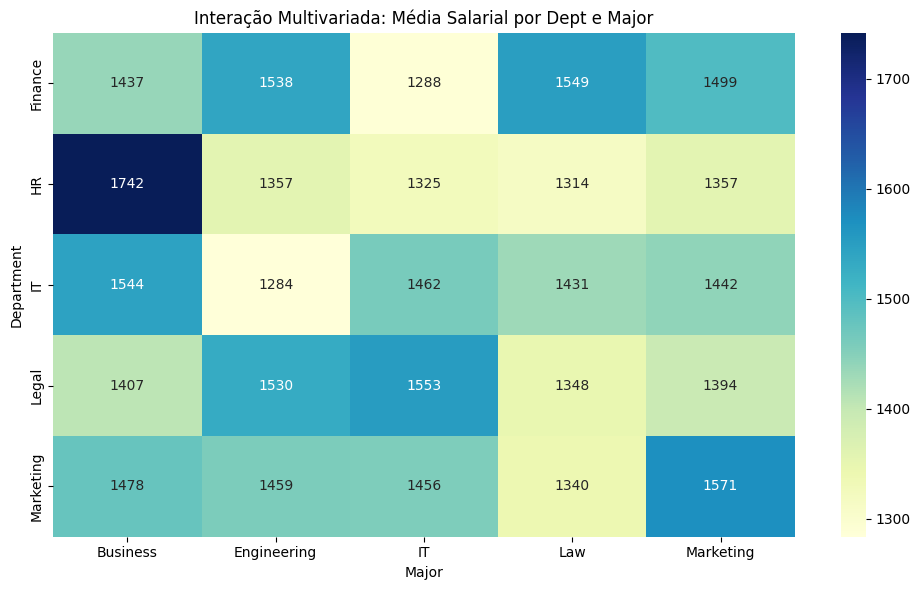

In [7]:
plt.figure(figsize=(10, 6))
pivot = df_raw.pivot_table(index='Department', columns='Major', values='Salary', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title('Interação Multivariada: Média Salarial por Dept e Major')

plt.tight_layout()
plt.savefig(FIGURES_UNDERSTANDING_DIR / "interacao_multivariada_salario_dept_major.png", bbox_inches="tight")
plt.show()

- O mapa de calor mostra que as médias salariais são consistentes na maioria das intersecções entre Departamento e Curso, oscilando aproximadamente entre **1300 e 1550**.

- Observa-se um único "ponto quente" no departamento de **HR** para colaboradores com curso de **Business** (≈ **1742**), representando a média mais elevada. Por outro lado, perfis de **IT** no departamento de **Finance** apresentam a média mais baixa (≈ **1288**).

- Salvo exceções pontuais, a combinação de curso e departamento não gera uma diferenciação salarial sistemática na empresa.

### 2) **Interação de Compromisso (Attendance vs Department):**
Cruzamos a variável com maior coeficiente de correlação bivariada com o Target (Attendance_%) e o Salary, segmentando por Department. O objetivo é validar se o rigor presencial é um determinante salarial específico de certas áreas funcionais, ou se a sua relevância é uniformemente nula.

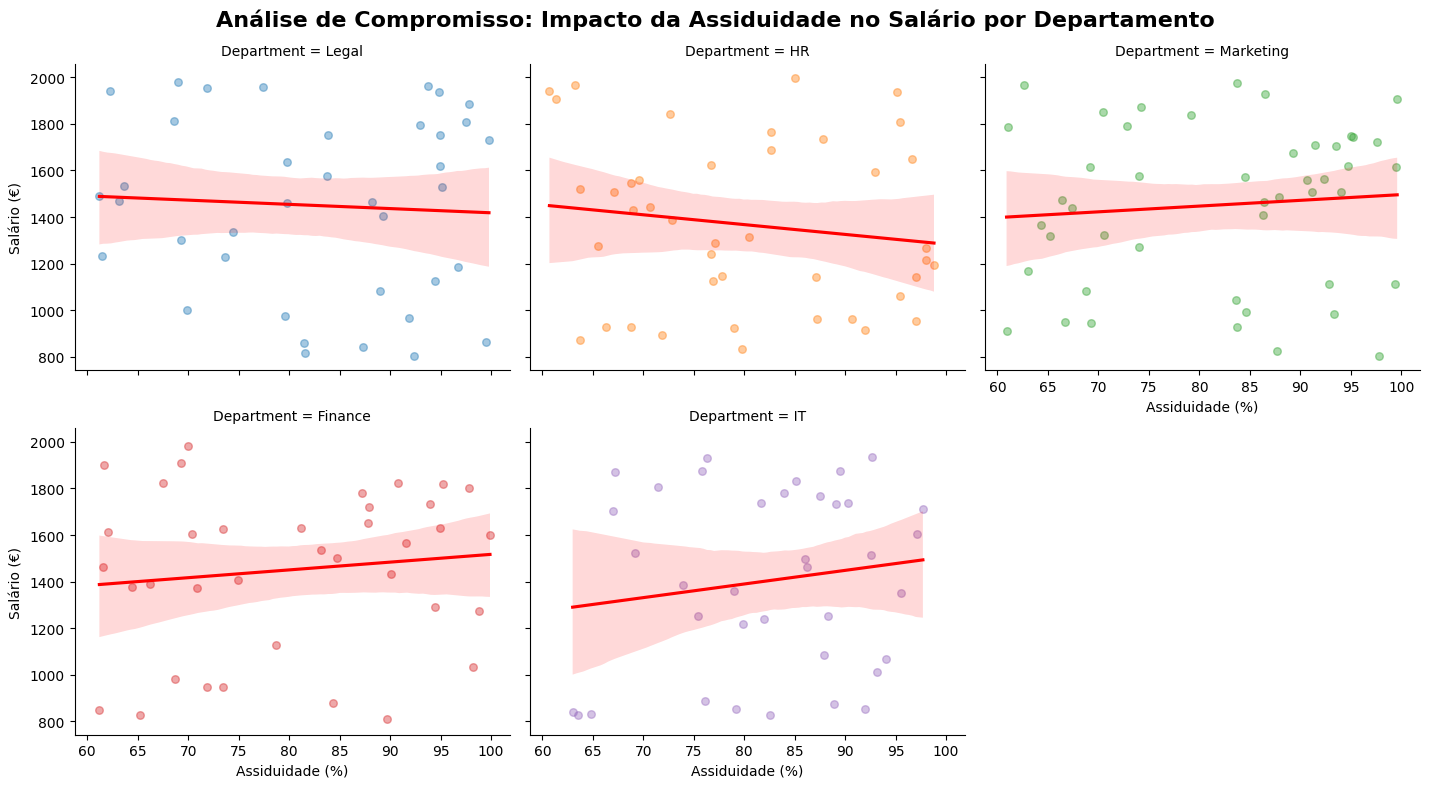

In [8]:
# Cria um gráfico de gráfico de dispersão com linha de regressão com múltiplos painéis (um por departamento)
grid = sns.lmplot(
    data=df_raw, 
    x='Attendance_%', 
    y='Salary', 
    hue='Department', 
    col='Department', 
    col_wrap=3, 
    height=4, 
    aspect=1.2,
    scatter_kws={'alpha': 0.4, 's': 30},
    line_kws={'color': 'red'})

# Define os rótulos dos eixos
grid.set_axis_labels("Assiduidade (%)", "Salário (€)")
grid.fig.subplots_adjust(top=0.9)
grid.fig.suptitle('Análise de Compromisso: Impacto da Assiduidade no Salário por Departamento', fontsize=16, fontweight='bold')

# Ajusta automaticamente os espaçamentos para evitar sobreposição
plt.tight_layout()
plt.savefig(FIGURES_UNDERSTANDING_DIR / "analise_compromisso_assiduidade_salario.png", bbox_inches="tight")
plt.show()

#### Interpretação:

**Neutralidade de Tendência:** As retas de regressão (slopes) aproximam-se da horizontalidade em quase todos os segmentos, indicando que a variação em `Attendance_%` não se traduz em incrementos salariais previsíveis.

**Elevada Dispersão:** A elevada dispersão dos pontos para níveis idênticos de assiduidade evidencia que o `Salary` é influenciado por fatores não mapeados ou por decisões subjetivas.

**Inconsistência por Segmento:** O comportamento errático das tendências entre departamentos (ex.: inclinação negativa em HR vs. positiva em IT) confirma que o ruído estatístico sobrepõe-se a qualquer “sinal” consistente de regra de negócio.

<br>

Text(0.5, 1.02, 'Relações Pairwise: Salary (target) vs Supervisor_Evaluation vs Attendance_%')

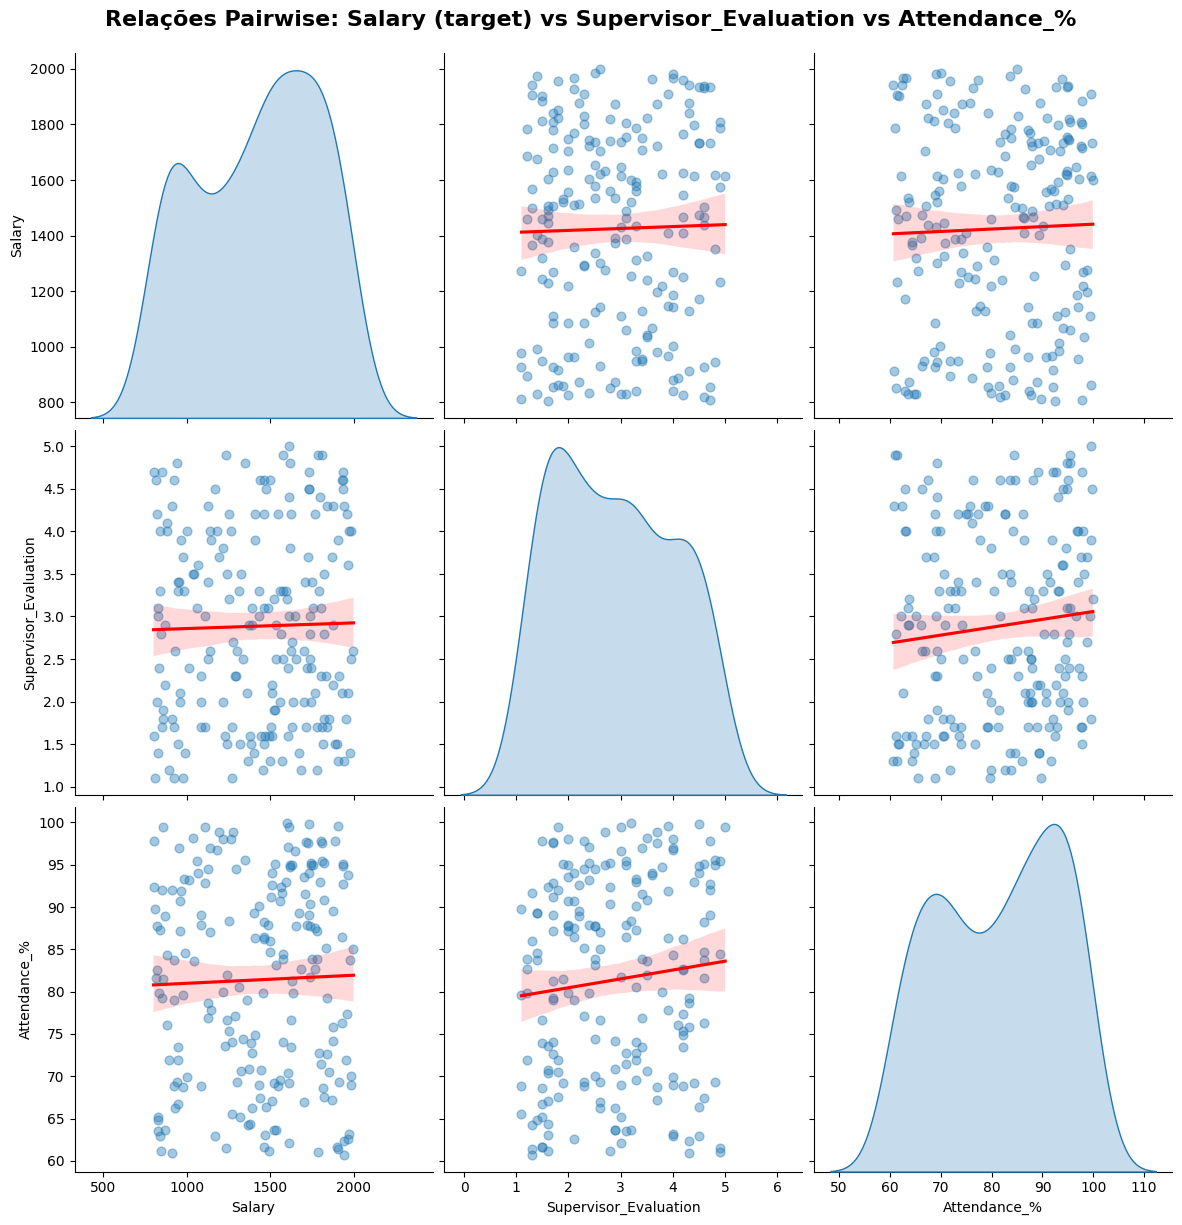

In [9]:
# ========================
# ANÁLISE MULTIVARIADA NUMÉRICA
# Salary vs Supervisor_Evaluation vs Attendance_%
# ========================

numerical_vars = ['Salary', 'Supervisor_Evaluation', 'Attendance_%']

# Create the pairplot
g = sns.pairplot(
    df_raw[numerical_vars],
    kind='reg',                      # scatter + regression line
    diag_kind='kde',                 # density plots on diagonal
    height=4,
    plot_kws={
        'line_kws': {'color': 'red'},
        'scatter_kws': {'alpha': 0.4, 's': 40}
    }
)

# Set global figure title
g.figure.suptitle(
    'Relações Pairwise: Salary (target) vs Supervisor_Evaluation vs Attendance_%',
    y=1.02, fontsize=16, fontweight='bold'
)

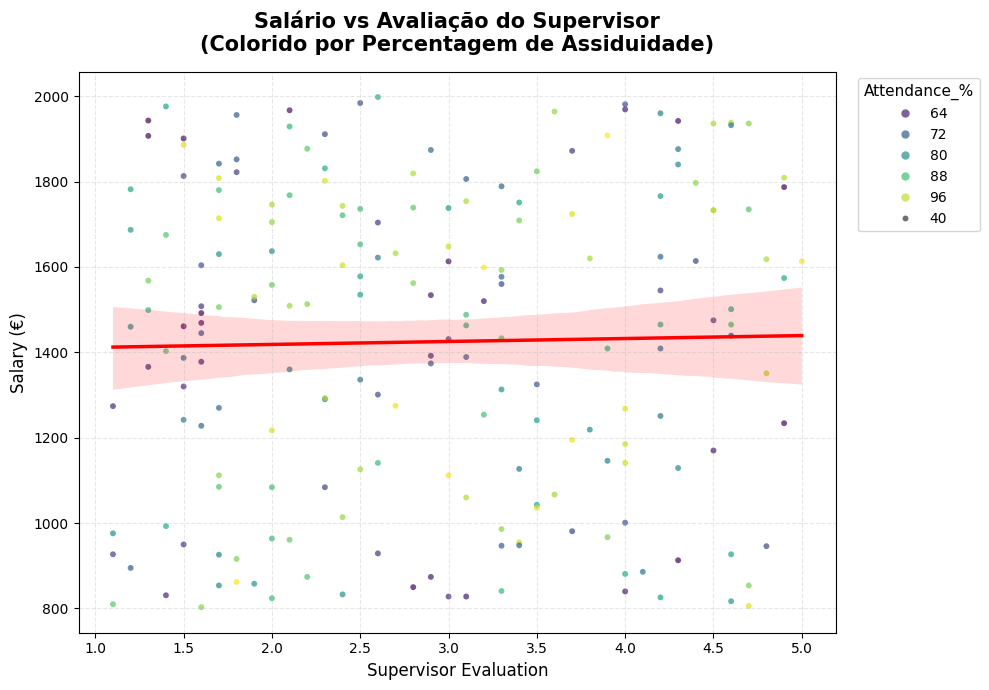

In [14]:
# =============================================================================
# Opção A: Scatter 2D com cor representando a terceira variável (recomendado)
# Supervisor_Evaluation (x) vs Salary (y), cor = Attendance_%
# =============================================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_raw,
    x='Supervisor_Evaluation',
    y='Salary',
    hue='Attendance_%',
    palette='viridis',          # gradiente perceptualmente uniforme
    alpha=0.7,
    size=40,
    edgecolor='none'
)

# Linha de regressão suave (lowess) para ajudar a ver tendência média
sns.regplot(
    data=df_raw,
    x='Supervisor_Evaluation',
    y='Salary',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2.5},
    lowess=False
)

plt.title('Salário vs Avaliação do Supervisor\n(Colorido por Percentagem de Assiduidade)', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Supervisor Evaluation', fontsize=12)
plt.ylabel('Salary (€)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Legenda da cor ajustada
plt.legend(title='Attendance_%', bbox_to_anchor=(1.02, 1), loc='upper left', 
           title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.savefig(
    FIGURES_UNDERSTANDING_DIR / "scatter_salary_vs_evaluation_colored_by_attendance.png",
    bbox_inches="tight", dpi=300
)
plt.show()

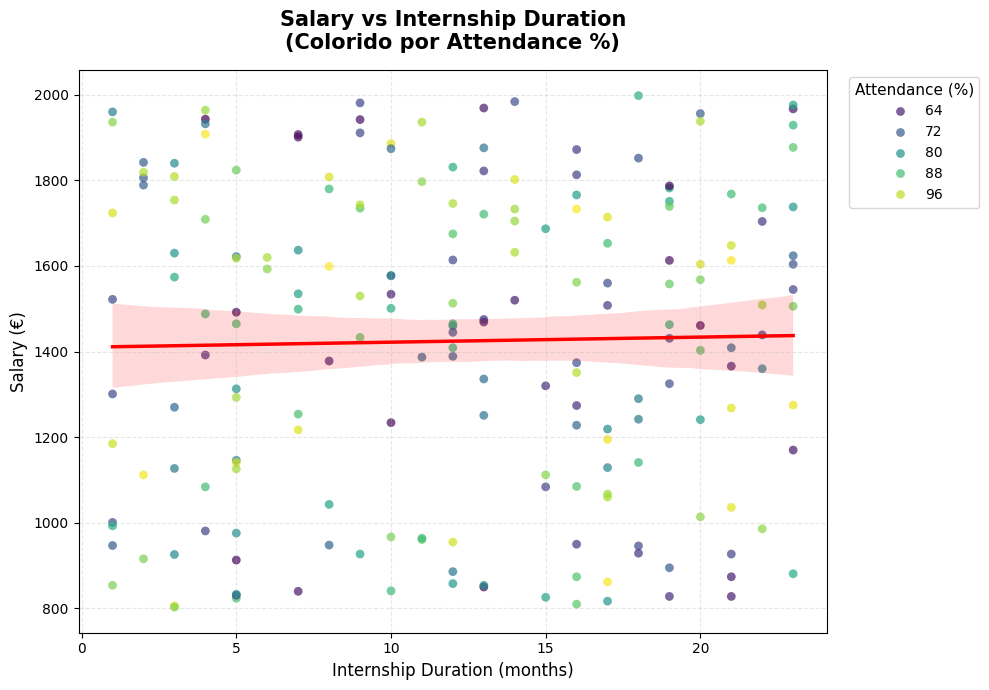

In [17]:
# =============================================================================
# Scatter 2D com cor representando a terceira variável (recomendado)
# Internship Duration (x) vs Salary (y), cor = Attendance_%
# =============================================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_raw,
    x='Internship_Duration_Months',
    y='Salary',
    hue='Attendance_%',
    palette='viridis',          # gradiente perceptualmente uniforme
    alpha=0.7,
    s=40,                       # tamanho dos pontos (corrigido: era 'size')
    edgecolor='none'
)

# Linha de regressão para tendência média
sns.regplot(
    data=df_raw,
    x='Internship_Duration_Months',
    y='Salary',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2.5},
    lowess=False
)

plt.title('Salary vs Internship Duration\n(Colorido por Attendance %)', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Internship Duration (months)', fontsize=12)
plt.ylabel('Salary (€)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Legenda da cor ajustada
plt.legend(
    title='Attendance (%)',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    title_fontsize=11,
    fontsize=10
)

plt.tight_layout()
plt.savefig(
    FIGURES_UNDERSTANDING_DIR / "scatter_salary_vs_duration_colored_by_attendance.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [11]:
# =============================================================================
# Opção B: Gráfico 3D interativo com plano de regressão linear múltipla
# =============================================================================

import plotly.graph_objects as go
import numpy as np
from sklearn.linear_model import LinearRegression

# Preparar dados
X = df_raw[['Supervisor_Evaluation', 'Attendance_%']].values
y = df_raw['Salary'].values

# Ajustar modelo linear múltiplo
model = LinearRegression()
model.fit(X, y)

# Criar malha para o plano
x_range = np.linspace(X[:,0].min(), X[:,0].max(), 30)
y_range = np.linspace(X[:,1].min(), X[:,1].max(), 30)
xx, yy = np.meshgrid(x_range, y_range)

# Previsões no plano
zz = model.intercept_ + model.coef_[0] * xx + model.coef_[1] * yy

# Figura interativa
fig = go.Figure()

# Pontos reais (scatter 3D)
fig.add_trace(go.Scatter3d(
    x=X[:,0], y=X[:,1], z=y,
    mode='markers',
    marker=dict(
        size=5,
        color=y,                # cor por salário (opcional: pode mudar para Attendance_%)
        colorscale='Viridis',
        opacity=0.7,
        showscale=True,
        colorbar_title='Salary (€)'
    ),
    name='Dados reais'
))

# Plano de regressão
fig.add_trace(go.Surface(
    x=xx, y=yy, z=zz,
    colorscale='Reds',
    opacity=0.4,
    showscale=False,
    name='Plano de regressão'
))

fig.update_layout(
    title='Relação 3D: Salary vs Supervisor_Evaluation vs Attendance_%\n(com plano de regressão linear)',
    scene=dict(
        xaxis_title='Supervisor Evaluation',
        yaxis_title='Attendance_%',
        zaxis_title='Salary (€)',
        bgcolor='rgba(0,0,0,0)',
        xaxis=dict(gridcolor='lightgray'),
        yaxis=dict(gridcolor='lightgray'),
        zaxis=dict(gridcolor='lightgray')
    ),
    height=700,
    margin=dict(l=0, r=0, b=0, t=50),
    scene_camera=dict(eye=dict(x=1.8, y=1.8, z=0.8))
)

# Guardar como HTML interativo (mais útil que png para 3D)
fig.write_html(
    FIGURES_UNDERSTANDING_DIR / "3d_scatter_regression_plane_salary.html"
)

# Mostrar no notebook
fig.show()

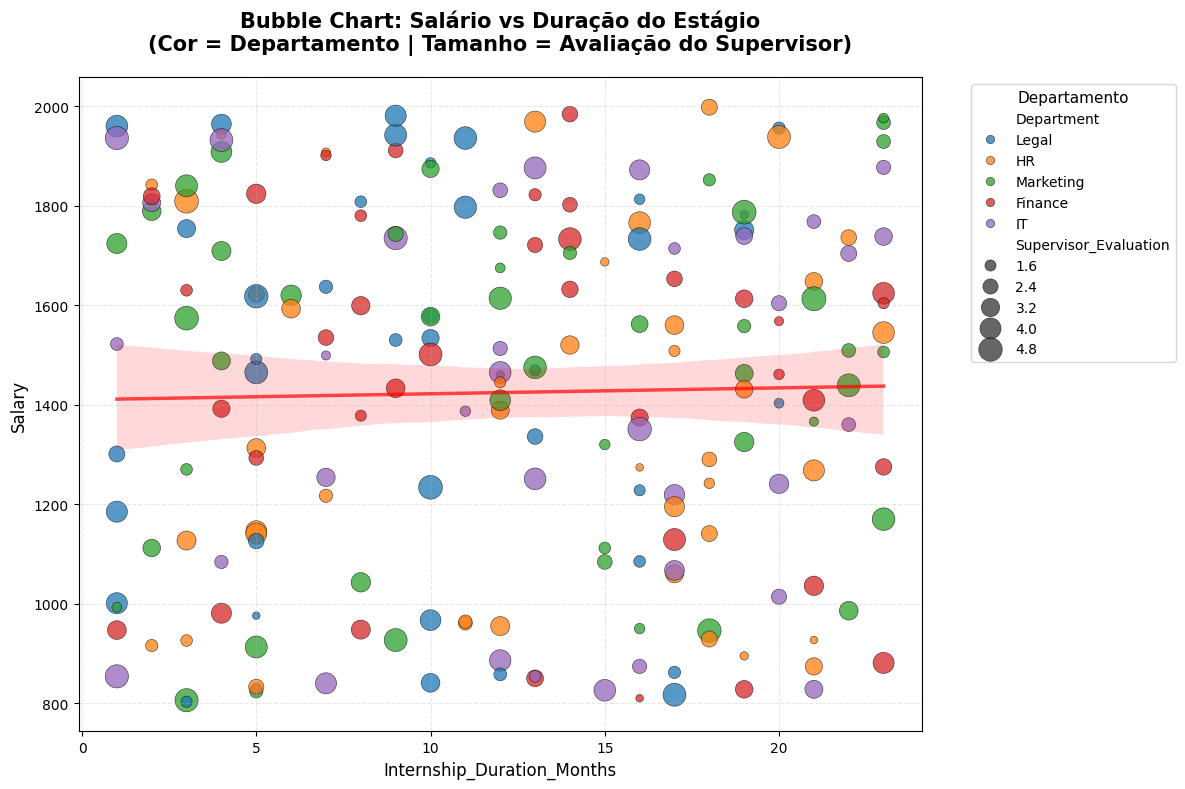

In [18]:
# =============================================================================
# BUBBLE CHART MULTIVARIADO (4 variáveis numéricas/categóricas num só gráfico)
# =============================================================================

plt.figure(figsize=(12, 8))

bubble = sns.scatterplot(
    data=df_raw,
    x='Internship_Duration_Months',
    y='Salary',
    hue='Department',                    # Cor por departamento
    size='Supervisor_Evaluation',        # Tamanho da bolha = avaliação
    palette='tab10',                     # Cores distintas para os 5 departamentos
    sizes=(30, 300),                     # Intervalo de tamanho das bolhas
    alpha=0.75,
    edgecolor='black',
    linewidth=0.4
)

plt.title('Bubble Chart: Salário vs Duração do Estágio\n'
          '(Cor = Departamento | Tamanho = Avaliação do Supervisor)',
          fontsize=15, fontweight='bold', pad=20)

plt.xlabel('Duração do Estágio (meses)', fontsize=12)
plt.ylabel('Salário (€)', fontsize=12)

# Melhorar legenda
plt.legend(
    title='Departamento',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10,
    title_fontsize=11
)

# Adicionar linha de tendência geral (opcional, mas útil)
sns.regplot(
    data=df_raw,
    x='Internship_Duration_Months',
    y='Salary',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2.5, 'alpha': 0.7},
    lowess=False
)

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Guardar
plt.savefig(
    FIGURES_UNDERSTANDING_DIR / "bubble_chart_salary_duration_department_evaluation.png",
    bbox_inches="tight", dpi=300
)
plt.show()

<hr>

# **Conclusão: Data Understanding**

A exploração exaustiva dos dados permitiu mapear a (ausência de) estrutura das variáveis em relação ao `Salary`. Os principais insights que fundamentam a próxima fase são:

---

### **1. Inexistência de Determinantes Estatísticos**
Nenhuma variável isolada — seja numérica (**Age**, **Evaluation**, **Attendance**) ou categórica (**Major**, **Department**) — apresenta correlação forte ou diferença estatística significativa. 
* **Evidência:** Os testes **ANOVA** resultaram em valores de $p$ extremamente elevados: **$0.9074$** para `Major` e **$0.7756$** para `Department`. 
* **Conclusão:** Falhámos em rejeitar a hipótese nula; as médias salariais são estatisticamente idênticas entre grupos, indicando uma distribuição uniforme (ou aleatória).

### **2. Desconexão entre Desempenho, Perfil e Remuneração** 
* **Desconexão com a Performance:** A correlação quase nula entre `Salary` e `Supervisor_Evaluation` ($r = 0.02$) prova que o mérito individual não é o motor da remuneração nesta amostra.
* **Neutralidade de Compromisso:** A análise multivariada de `Attendance_%` vs `Department` revelou retas de tendência horizontais e dispersão residual extrema. O "rigor presencial" é ignorado na definição salarial em todos os departamentos.

### **3. Evidência de Subjetividade Estrutural**
A ausência de padrões lineares e a sobreposição total de distribuições sugerem que o salário é definido por critérios subjetivos ou variáveis externas ao dataset. O **ruído estatístico** domina o sinal, validando a tese inicial de falta de transparência nas políticas de RH.

---

### **Observação Final para Modelação**
Estamos perante um cenário de **baixa fidelidade preditiva**.
Para a próxima fase:
1. A **Regressão Linear** servirá apenas como *baseline* de falha (expectativa de $R^2$ próximo de zero).
2. A exploração de modelos não-lineares (**Decision Trees** e **Random Forests**) será a última tentativa de encontrar regras de interação complexas que a estatística bivariada não conseguiu detetar.